In [12]:
from utils import get_list_differences
import polars as pl
import os 

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
DATA_ROOT = '/scratch/combined_datasets'

## Look at cell to cluster mapping of patchseq and WNM

In [15]:
df = pl.read_delta(os.path.join(DATA_ROOT, 'celltoclustermapping'))

In [16]:
df

id,mapping_set,source_cell,target_cluster,score,probability,notes,project_id
str,str,str,str,f64,f64,str,str
"""182709_6984-X2452-Y12423_reg-L…","""visp_exc_wnm_mettype_mapping""","""182709_6984-X2452-Y12423_reg""","""L5 ET-2""",null,0.988,null,"""visp_exc_wnm"""
"""182709_6984-X2452-Y12423_reg-G…","""visp_exc_wnm_mettype_mapping""","""182709_6984-X2452-Y12423_reg""","""Glutamatergic""",null,null,null,"""visp_exc_wnm"""
"""182709_6984-X2452-Y12423_reg-c…","""visp_exc_wnm_mettype_mapping""","""182709_6984-X2452-Y12423_reg""","""cell""",null,null,null,"""visp_exc_wnm"""
"""182709_7126-X2913-Y10535_reg-L…","""visp_exc_wnm_mettype_mapping""","""182709_7126-X2913-Y10535_reg""","""L5 ET-3""",null,0.918,null,"""visp_exc_wnm"""
"""182709_7126-X2913-Y10535_reg-G…","""visp_exc_wnm_mettype_mapping""","""182709_7126-X2913-Y10535_reg""","""Glutamatergic""",null,null,null,"""visp_exc_wnm"""
…,…,…,…,…,…,…,…
"""645369849-cell-visp_exc_patchs…","""visp_exc_patchseq_ttype_mappin…","""645369849""","""cell""",null,null,null,"""visp_exc_patchseq"""
"""831254527-L6 CT VISp Ctxn3 Sla…","""visp_exc_patchseq_ttype_mappin…","""831254527""","""L6 CT VISp Ctxn3 Sla""",null,null,null,"""visp_exc_patchseq"""
"""831254527-L6 CT-visp_exc_patch…","""visp_exc_patchseq_ttype_mappin…","""831254527""","""L6 CT""",null,null,null,"""visp_exc_patchseq"""


In [19]:
df['mapping_set'].unique()

mapping_set
str
"""visp_exc_wnm_mettype_mapping"""
"""visp_exc_patchseq_ttype_mappin…"
"""visp_inh_patchseq_ttype_mappin…"


In [29]:
df = pl.read_delta('/data/visp_deltalakes/cluster')
df

id,parent,children,level,score,hex_color,heirachy_category,distance_to_parent,project_id
str,str,list[str],i64,f64,str,str,f64,str
"""cell""",null,"[""GABAergic"", ""Glutamatergic""]",0,null,"""#000000""","""major_class""",null,"""visp_met_types"""
"""GABAergic""","""cell""","[""Sst-MET-1"", ""Sst-MET-2"", … ""Vip-MET-5""]",1,null,"""#EF4136""","""class""",null,"""visp_met_types"""
"""Glutamatergic""","""cell""","[""L2/3 IT"", ""L4 IT"", … ""L6b""]",1,null,"""#27AAE1""","""class""",null,"""visp_met_types"""
"""Sst-MET-1""","""GABAergic""",null,2,null,"""#b9bb67""","""cluster""",null,"""visp_met_types"""
"""Sst-MET-2""","""GABAergic""",null,2,null,"""#804811""","""cluster""",null,"""visp_met_types"""
…,…,…,…,…,…,…,…,…
"""L6b Hsd17b2""","""L6b""",null,3,null,"""#335280""","""cluster""",null,"""tasic_2018_visp_scrnaseq"""
"""VLMC Spp1 Hs3st6""","""VLMC""",null,3,null,"""#6B8059""","""cluster""",null,"""tasic_2018_visp_scrnaseq"""
"""SMC Acta2""","""SMC""",null,3,null,"""#807059""","""cluster""",null,"""tasic_2018_visp_scrnaseq"""


In [30]:
df = pl.read_delta('/data/visp_deltalakes/clustermembership')
df

item,cluster,membership_score,probability,distance,project_id
str,str,f64,f64,f64,str
"""1039273993""","""L6b""",null,null,null,"""visp_exc_patchseq"""
"""1039273993""","""Glutamatergic""",null,null,null,"""visp_exc_patchseq"""
"""1039273993""","""cell""",null,null,null,"""visp_exc_patchseq"""
"""823218199""","""L5 ET-3""",null,null,null,"""visp_exc_patchseq"""
"""823218199""","""Glutamatergic""",null,null,null,"""visp_exc_patchseq"""
…,…,…,…,…,…
"""993245688""","""GABAergic""",null,null,null,"""visp_inh_patchseq"""
"""993245688""","""cell""",null,null,null,"""visp_inh_patchseq"""
"""993283588""","""Sncg-MET-1""",null,null,null,"""visp_inh_patchseq"""


In [31]:
df['project_id'].unique()

project_id
str
"""visp_exc_patchseq"""
"""visp_inh_patchseq"""


In [32]:
df = pl.read_delta('/data/visp_deltalakes/celltoclustermapping')
df

id,mapping_set,source_cell,target_cluster,score,probability,notes,project_id
str,str,str,str,f64,f64,str,str
"""182709_6984-X2452-Y12423_reg-L…","""visp_exc_wnm_mettype_mapping""","""182709_6984-X2452-Y12423_reg""","""L5 ET-2""",null,0.988,null,"""visp_exc_wnm"""
"""182709_6984-X2452-Y12423_reg-G…","""visp_exc_wnm_mettype_mapping""","""182709_6984-X2452-Y12423_reg""","""Glutamatergic""",null,null,null,"""visp_exc_wnm"""
"""182709_6984-X2452-Y12423_reg-c…","""visp_exc_wnm_mettype_mapping""","""182709_6984-X2452-Y12423_reg""","""cell""",null,null,null,"""visp_exc_wnm"""
"""182709_7126-X2913-Y10535_reg-L…","""visp_exc_wnm_mettype_mapping""","""182709_7126-X2913-Y10535_reg""","""L5 ET-3""",null,0.918,null,"""visp_exc_wnm"""
"""182709_7126-X2913-Y10535_reg-G…","""visp_exc_wnm_mettype_mapping""","""182709_7126-X2913-Y10535_reg""","""Glutamatergic""",null,null,null,"""visp_exc_wnm"""
…,…,…,…,…,…,…,…
"""738925092-cell-visp_inh_patchs…","""visp_inh_patchseq_ttype_mappin…","""738925092""","""cell""",null,null,null,"""visp_inh_patchseq"""
"""772422057-Pvalb Th Sst-visp_in…","""visp_inh_patchseq_ttype_mappin…","""772422057""","""Pvalb Th Sst""",null,null,null,"""visp_inh_patchseq"""
"""772422057-Pvalb-visp_inh_patch…","""visp_inh_patchseq_ttype_mappin…","""772422057""","""Pvalb""",null,null,null,"""visp_inh_patchseq"""


In [33]:
df['project_id'].unique()

project_id
str
"""visp_exc_patchseq"""
"""visp_exc_wnm"""
"""visp_inh_patchseq"""


- LOL annoyed:
    - **visp_exc_patchseq** — has ClusterMembership entries to **the visp_met_types**
    - **visp_exc_wnm** → mapped to **visp_met_types** and is stored in celltoClusterMapping
    - so when i want “all cells that HAVE visp_met_types” they are not in one place!

---
## UMAP-based Label Transfer: patchseq (VISp EXC) → minnie65 (EXC)

Pipeline:
1. Load patchseq excitatory morph features + MET-type cluster labels
2. Load minnie excitatory skeleton-keys features
3. Identify shared features dynamically; drop NaN rows
4. Fit `StandardScaler` on patchseq, transform both
5. Fit `UMAP` on patchseq, `.transform()` minnie into the same embedding
6. 3-NN majority-vote label transfer from patchseq → minnie
7. Visualise

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.stats import mode
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

### Phase 1 — Load Data

In [15]:
# Patchseq excitatory morphology features
df_ps_feat = pl.read_delta(os.path.join(DATA_ROOT, 'cellfeatures/exc_morph_features'))
df_ps_feat = df_ps_feat.filter(
    (pl.col('project_id') == 'visp_exc_patchseq') &
    (pl.col('feature_set_id') == 'exc_visp_morph_features')
)
print(f"Patchseq features: {df_ps_feat.shape}")
df_ps_feat.head(3)

Patchseq features: (389, 53)


id,apical_dendrite_bias_x,apical_dendrite_bias_y,apical_dendrite_depth_pc_0,apical_dendrite_depth_pc_1,apical_dendrite_depth_pc_2,apical_dendrite_depth_pc_3,apical_dendrite_early_branch_path,apical_dendrite_emd_with_basal_dendrite,apical_dendrite_extent_x,apical_dendrite_extent_y,apical_dendrite_frac_above_basal_dendrite,apical_dendrite_frac_below_basal_dendrite,apical_dendrite_frac_intersect_basal_dendrite,apical_dendrite_max_branch_order,apical_dendrite_max_euclidean_distance,apical_dendrite_max_path_distance,apical_dendrite_mean_contraction,apical_dendrite_mean_diameter,apical_dendrite_mean_moments_along_max_distance_projection,apical_dendrite_num_branches,apical_dendrite_num_outer_bifurcations,apical_dendrite_soma_percentile_x,apical_dendrite_soma_percentile_y,apical_dendrite_std_moments_along_max_distance_projection,apical_dendrite_total_length,apical_dendrite_total_surface_area,axon_exit_distance,axon_exit_theta,basal_dendrite_bias_x,basal_dendrite_bias_y,basal_dendrite_calculate_number_of_stems,basal_dendrite_extent_x,basal_dendrite_extent_y,basal_dendrite_frac_above_apical_dendrite,basal_dendrite_frac_below_apical_dendrite,basal_dendrite_frac_intersect_apical_dendrite,basal_dendrite_max_branch_order,basal_dendrite_max_euclidean_distance,basal_dendrite_max_path_distance,basal_dendrite_mean_contraction,basal_dendrite_mean_diameter,basal_dendrite_num_branches,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,project_id,feature_set_id
str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,f32,f32,f32,str,str
"""601628311""",147.076721,388.737335,-0.134846,-7.323705,-16.31525,2.834573,0.377581,63.287174,303.832245,430.002777,0.647374,0.0,0.352626,9,412.426788,535.364746,0.880161,0.903242,0.395395,21,0.778151,0.199797,0.022312,0.297191,1513.543823,4145.918457,0.0,0.676106,190.920303,-215.522324,3,298.811951,262.765289,0.0,0.477325,0.522675,8,381.776184,445.646149,0.886983,0.738017,29,0.210607,0.859339,0.0,1.0,0.0,1842.712524,4251.727539,543.539917,"""visp_exc_patchseq""","""exc_visp_morph_features"""
"""603229579""",117.918472,513.295654,181.612076,-49.761566,75.880211,18.681379,0.272368,49.58083,323.203125,680.002136,0.76549,0.0,0.23451,18,614.681091,779.244324,0.918641,0.765617,0.417079,63,1.113943,0.280784,0.083137,0.385682,3165.540771,7558.615234,0.0,0.566352,6.077639,-85.867607,4,219.374954,150.459167,0.0,0.033118,0.966882,5,146.587982,167.992691,0.898062,0.678512,30,0.468498,0.894992,0.0,1.0,0.0,1559.948242,3349.079102,541.661499,"""visp_exc_patchseq""","""exc_visp_morph_features"""
"""603337985""",74.871315,382.300995,-77.738235,-19.625267,-50.744755,-86.666443,0.384813,13.400125,254.446243,446.575012,0.248392,0.0,0.751608,7,436.830353,504.563934,0.85786,0.68569,0.154741,25,0.30103,0.242765,0.057074,0.239363,1463.44458,3153.132812,0.0,0.777599,19.367064,75.317406,4,192.531525,190.774384,0.0,0.0,1.0,5,146.894363,176.792923,0.850834,0.635489,28,0.223268,0.305389,0.25,0.5,0.25,1467.914917,2933.82251,458.134216,"""visp_exc_patchseq""","""exc_visp_morph_features"""


In [16]:
# Diagnose: how many clustermembership rows per patchseq cell?
df_ps_labels_raw = (
    pl.read_delta(os.path.join(DATA_ROOT, 'clustermembership'))
    .filter(pl.col('project_id') == 'visp_exc_patchseq')
)

rows_per_cell = (
    df_ps_labels_raw
    .group_by('item')
    .agg(pl.len().alias('n_rows'))
)
print("Rows per cell distribution:")
print(rows_per_cell['n_rows'].value_counts().sort('n_rows'))

# Check what hierarchy categories are present
df_clusters = pl.read_delta(os.path.join(DATA_ROOT, 'cluster'))
df_ps_labels_with_level = df_ps_labels_raw.join(
    df_clusters.select(['id', 'level', 'heirachy_category']),
    left_on='cluster', right_on='id',
    how='left'
)
print("\nClusters by hierarchy category:")
print(df_ps_labels_with_level.group_by('heirachy_category').agg(pl.len().alias('count')).sort('count', descending=True))

Rows per cell distribution:
shape: (1, 2)
┌────────┬───────┐
│ n_rows ┆ count │
│ ---    ┆ ---   │
│ u32    ┆ u32   │
╞════════╪═══════╡
│ 3      ┆ 384   │
└────────┴───────┘

Clusters by hierarchy category:
shape: (4, 2)
┌───────────────────┬───────┐
│ heirachy_category ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ class             ┆ 768   │
│ major_class       ┆ 768   │
│ cluster           ┆ 384   │
│ subclass          ┆ 93    │
└───────────────────┴───────┘


In [17]:
# Keep only the deepest (most specific) cluster label per patchseq cell.
# Patchseq cells map to visp_met_types clusters -- filter cluster table to that project first.
df_clusters_met = df_clusters.filter(pl.col('project_id') == 'visp_met_types')

df_ps_labels = (
    df_ps_labels_raw
    .select(['item', 'cluster'])
    .join(
        df_clusters_met.select(['id', 'level', 'heirachy_category']),
        left_on='cluster', right_on='id',
        how='left'
    )
    # Per cell, keep the row with the highest level (deepest / most specific)
    .sort('level', descending=True, nulls_last=True)
    .group_by('item')
    .first()
    .select(['item', 'cluster', 'level', 'heirachy_category'])
)

print('Label distribution by hierarchy category:')
print(df_ps_labels.group_by('heirachy_category').agg(pl.len().alias('count')).sort('count', descending=True))
print(f'\nUnique cells:  {df_ps_labels["item"].n_unique()}')
print(f'Unique labels: {df_ps_labels["cluster"].n_unique()}')
df_ps_labels.head(5)

Label distribution by hierarchy category:
shape: (1, 2)
┌───────────────────┬───────┐
│ heirachy_category ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ cluster           ┆ 384   │
└───────────────────┴───────┘

Unique cells:  384
Unique labels: 17


item,cluster,level,heirachy_category
str,str,i64,str
"""912889454""","""L2/3 IT""",2,"""cluster"""
"""961238333""","""L5 IT-3 Pld5""",2,"""cluster"""
"""932678695""","""L6 CT-1""",2,"""cluster"""
"""961226203""","""L5 NP""",2,"""cluster"""
"""945833568""","""L5 IT-1""",2,"""cluster"""


In [30]:
# Join leaf-level labels onto features
df_ps = df_ps_feat.join(df_ps_labels, left_on='id', right_on='item', how='inner')
print(f"Patchseq after label join: {df_ps.shape}")
df_ps.head(5)

Patchseq after label join: (384, 56)


id,apical_dendrite_bias_x,apical_dendrite_bias_y,apical_dendrite_depth_pc_0,apical_dendrite_depth_pc_1,apical_dendrite_depth_pc_2,apical_dendrite_depth_pc_3,apical_dendrite_early_branch_path,apical_dendrite_emd_with_basal_dendrite,apical_dendrite_extent_x,apical_dendrite_extent_y,apical_dendrite_frac_above_basal_dendrite,apical_dendrite_frac_below_basal_dendrite,apical_dendrite_frac_intersect_basal_dendrite,apical_dendrite_max_branch_order,apical_dendrite_max_euclidean_distance,apical_dendrite_max_path_distance,apical_dendrite_mean_contraction,apical_dendrite_mean_diameter,apical_dendrite_mean_moments_along_max_distance_projection,apical_dendrite_num_branches,apical_dendrite_num_outer_bifurcations,apical_dendrite_soma_percentile_x,apical_dendrite_soma_percentile_y,apical_dendrite_std_moments_along_max_distance_projection,apical_dendrite_total_length,apical_dendrite_total_surface_area,axon_exit_distance,axon_exit_theta,basal_dendrite_bias_x,basal_dendrite_bias_y,basal_dendrite_calculate_number_of_stems,basal_dendrite_extent_x,basal_dendrite_extent_y,basal_dendrite_frac_above_apical_dendrite,basal_dendrite_frac_below_apical_dendrite,basal_dendrite_frac_intersect_apical_dendrite,basal_dendrite_max_branch_order,basal_dendrite_max_euclidean_distance,basal_dendrite_max_path_distance,basal_dendrite_mean_contraction,basal_dendrite_mean_diameter,basal_dendrite_num_branches,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,project_id,feature_set_id,cluster,level,heirachy_category
str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,f32,f32,f32,str,str,str,i64,str
"""601628311""",147.076721,388.737335,-0.134846,-7.323705,-16.31525,2.834573,0.377581,63.287174,303.832245,430.002777,0.647374,0.0,0.352626,9,412.426788,535.364746,0.880161,0.903242,0.395395,21,0.778151,0.199797,0.022312,0.297191,1513.543823,4145.918457,0.0,0.676106,190.920303,-215.522324,3,298.811951,262.765289,0.0,0.477325,0.522675,8,381.776184,445.646149,0.886983,0.738017,29,0.210607,0.859339,0.0,1.0,0.0,1842.712524,4251.727539,543.539917,"""visp_exc_patchseq""","""exc_visp_morph_features""","""L5 IT-2""",2,"""cluster"""
"""603229579""",117.918472,513.295654,181.612076,-49.761566,75.880211,18.681379,0.272368,49.58083,323.203125,680.002136,0.76549,0.0,0.23451,18,614.681091,779.244324,0.918641,0.765617,0.417079,63,1.113943,0.280784,0.083137,0.385682,3165.540771,7558.615234,0.0,0.566352,6.077639,-85.867607,4,219.374954,150.459167,0.0,0.033118,0.966882,5,146.587982,167.992691,0.898062,0.678512,30,0.468498,0.894992,0.0,1.0,0.0,1559.948242,3349.079102,541.661499,"""visp_exc_patchseq""","""exc_visp_morph_features""","""L5 ET-2""",2,"""cluster"""
"""603337985""",74.871315,382.300995,-77.738235,-19.625267,-50.744755,-86.666443,0.384813,13.400125,254.446243,446.575012,0.248392,0.0,0.751608,7,436.830353,504.563934,0.85786,0.68569,0.154741,25,0.30103,0.242765,0.057074,0.239363,1463.44458,3153.132812,0.0,0.777599,19.367064,75.317406,4,192.531525,190.774384,0.0,0.0,1.0,5,146.894363,176.792923,0.850834,0.635489,28,0.223268,0.305389,0.25,0.5,0.25,1467.914917,2933.82251,458.134216,"""visp_exc_patchseq""","""exc_visp_morph_features""","""L4 IT""",2,"""cluster"""
"""603481505""",130.585617,424.042572,309.580627,-48.441029,104.774864,-43.013512,0.37021,45.136787,355.122406,644.199158,0.597045,0.0,0.402955,20,564.46106,831.234009,0.81778,0.971846,0.382736,75,1.230449,0.243337,0.17613,0.342804,5530.317383,16620.470703,0.0,0.58749,3.566612,-62.815819,6,242.697159,149.831894,0.0,0.0,1.0,4,151.566345,196.850922,0.781844,0.836733,42,0.395452,0.840821,0.0,0.833333,0.166667,2744.146729,7285.432129,498.644318,"""visp_exc_patchseq""","""exc_visp_morph_features""","""L5 ET-3""",2

In [31]:
# Minnie65 excitatory skeleton-keys features
df_mn = pl.read_delta(os.path.join(DATA_ROOT, 'cellfeatures/minnie_exc_skel_keys'))
df_mn = df_mn.filter(
    (pl.col('project_id') == 'minnie65') &
    (pl.col('feature_set_id') == 'minnie_exc_skel_keys')
)
print(f"Minnie features: {df_mn.shape}")
df_mn.head(3)

Minnie features: (49714, 58)


id,apical_dendrite_bias_x,apical_dendrite_bias_y,apical_dendrite_depth_pc_0,apical_dendrite_depth_pc_1,apical_dendrite_depth_pc_2,apical_dendrite_depth_pc_3,apical_dendrite_early_branch_path,apical_dendrite_emd_with_basal_dendrite,apical_dendrite_extent_x,apical_dendrite_extent_y,apical_dendrite_frac_above_basal_dendrite,apical_dendrite_frac_below_basal_dendrite,apical_dendrite_frac_intersect_basal_dendrite,apical_dendrite_max_branch_order,apical_dendrite_max_euclidean_distance,apical_dendrite_max_path_distance,apical_dendrite_mean_contraction,apical_dendrite_mean_diameter,apical_dendrite_mean_moments_along_max_distance_projection,apical_dendrite_num_branches,apical_dendrite_num_outer_bifurcations,apical_dendrite_soma_percentile_x,apical_dendrite_soma_percentile_y,apical_dendrite_std_moments_along_max_distance_projection,apical_dendrite_total_length,apical_dendrite_total_surface_area,basal_dendrite_bias_x,basal_dendrite_bias_y,basal_dendrite_calculate_number_of_stems,basal_dendrite_depth_pc_0,basal_dendrite_depth_pc_1,basal_dendrite_depth_pc_2,basal_dendrite_depth_pc_3,basal_dendrite_depth_pc_4,basal_dendrite_depth_pc_5,basal_dendrite_extent_x,basal_dendrite_extent_y,basal_dendrite_frac_above_apical_dendrite,basal_dendrite_frac_below_apical_dendrite,basal_dendrite_frac_intersect_apical_dendrite,basal_dendrite_max_branch_order,basal_dendrite_max_euclidean_distance,basal_dendrite_max_path_distance,basal_dendrite_mean_contraction,basal_dendrite_mean_diameter,basal_dendrite_num_branches,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,soma_surface_area,project_id,feature_set_id
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""23141""",-0.04521,-1.384222,-0.410158,0.045882,-0.226091,-0.080629,0.961998,-1.610181,-0.964527,-2.319777,-2.160185,-0.108949,2.239043,-0.296803,-1.92104,-1.995027,0.756365,0.530112,1.204267,-0.397051,-0.080108,-0.638886,-0.205582,-0.202983,-1.303398,-1.237013,0.235982,0.506908,0.188345,-0.80893,-0.256701,-0.364127,0.232833,-0.16852,-0.205104,-0.830122,-0.148274,0.772298,0.831466,-1.062512,-0.19596,-0.15391,-0.184434,-0.057903,0.465465,-0.579885,0.11612,-0.171542,-0.097633,0.014659,0.082974,-1.662646,-1.441727,-1.317748,0.745332,"""minnie65""","""minnie_exc_skel_keys"""
"""23332""",0.723369,-1.090688,-0.155651,0.233851,-0.322193,-0.004184,-1.219603,-0.879759,0.81261,-1.851343,0.622234,-0.108949,-0.612109,-0.633313,-0.580297,-0.719134,0.542376,-0.824051,-0.473307,-0.397051,-0.636854,-0.373541,-0.205582,0.846114,-0.938483,-0.971629,-0.014252,-0.009848,0.188345,-1.127401,-0.076662,-0.754333,0.048782,-0.128814,0.224323,-0.515056,-0.515608,-0.118681,1.535554,-1.524482,-0.53247,-0.426436,-0.5294,0.895794,-1.688213,-0.579885,-0.049596,0.765459,0.271329,-0.723266,0.451937,-1.304668,-1.354976,-1.300258,-1.43003,"""minnie65""","""minnie_exc_skel_keys"""
"""23373""",-0.321714,-1.481655,-0.421491,-0.010684,-0.227657,-0.051772,0.533187,-1.305333,-1.455956,-2.433953,1.911647,-0.108949,-1.933375,-0.633313,-2.038467,-2.096864,-1.641971,0.634501,0.362192,-0.729367,-0.636854,0.047247,-0.205582,-1.186027,-1.396392,-1.328219,-0.003421,-0.350165,-1.281804,-0.535032,-0.314891,0.040967,-0.077544,-0.282559,-0.189412,-1.680826,-0.826135,-0.118681,2.1377,-2.135473,-0.53247,-0.656033,-0.714519,0.430691,-0.13904,-1.410675,-0.352099,1.367432,-0.097633,-0.262063,0.359696,-2.110242,-1.877541,-1.323333,-0.598073,"""minnie65""","""minnie_exc_skel_keys"""


### Phase 2 — Feature Harmonization

In [32]:
META_COLS = {'id', 'project_id', 'feature_set_id', 'cluster'}

ps_feat_cols = [c for c in df_ps.columns if c not in META_COLS]
mn_feat_cols = [c for c in df_mn.columns if c not in META_COLS]

only_in_ps, only_in_mn = get_list_differences(ps_feat_cols, mn_feat_cols, return_lists=True)
shared_features = sorted(set(ps_feat_cols) & set(mn_feat_cols))

print(f"Shared features:    {len(shared_features)}")
print(f"Only in patchseq:   {len(only_in_ps)}  → {only_in_ps}")
print(f"Only in minnie:     {len(only_in_mn)}  → {only_in_mn}")

ONLY IN A                      | ONLY IN B                     
------------------------------------------------------------
heirachy_category              | basal_dendrite_depth_pc_4     
level                          | soma_surface_area             
axon_exit_theta                | basal_dendrite_depth_pc_1     
axon_exit_distance             | basal_dendrite_depth_pc_5     
                               | basal_dendrite_depth_pc_0     
                               | basal_dendrite_depth_pc_3     
                               | basal_dendrite_depth_pc_2     


Shared features:    48
Only in patchseq:   4  → ['heirachy_category', 'level', 'axon_exit_theta', 'axon_exit_distance']
Only in minnie:     7  → ['basal_dendrite_depth_pc_4', 'soma_surface_area', 'basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_5', 'basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_2']


In [33]:
# Subset to shared features, convert to pandas
df_ps_pd = df_ps.select(shared_features + ['cluster']).to_pandas()
df_mn_pd = df_mn.select(shared_features + ['id']).to_pandas()

# Drop NaN rows and report
ps_before, mn_before = len(df_ps_pd), len(df_mn_pd)
df_ps_pd = df_ps_pd.dropna(subset=shared_features)
df_mn_pd = df_mn_pd.dropna(subset=shared_features)

print(f"Patchseq: {ps_before} → {len(df_ps_pd)} rows (dropped {ps_before - len(df_ps_pd)})")
print(f"Minnie:   {mn_before} → {len(df_mn_pd)} rows (dropped {mn_before - len(df_mn_pd)})")

Patchseq: 384 → 384 rows (dropped 0)
Minnie:   49714 → 49714 rows (dropped 0)


### Phase 3 — Scaling

In [34]:
# Fit scaler on patchseq, transform both
scaler = StandardScaler()
X_ps = scaler.fit_transform(df_ps_pd[shared_features].values)
X_mn = scaler.transform(df_mn_pd[shared_features].values)

print(f"Scaled patchseq: {X_ps.shape}")
print(f"Scaled minnie:   {X_mn.shape}")

Scaled patchseq: (384, 48)
Scaled minnie:   (49714, 48)


#### Phase 3 — Distribution Diagnostics

Visualise how well the two datasets align **before and after** `StandardScaler`:

- **Metrics cell** → `alignment_df`: per-feature |Δ mean| and std ratio (minnie / patchseq), sorted by post-scaling Δmean.
- **Bar chart** → all features at a glance; ideal result is near-zero Δmean and std ratio ≈ 1 after scaling.
- **Histograms** → overlaid density plots for the `TOP_N` best- and worst-aligned features (green background = best, red = worst).


In [35]:
# ── Phase 3 Diagnostics: compute per-feature alignment metrics ────────────────
# Raw arrays (before scaling)
raw_ps = df_ps_pd[shared_features].values
raw_mn = df_mn_pd[shared_features].values

mean_ps_raw = raw_ps.mean(axis=0)
mean_mn_raw = raw_mn.mean(axis=0)
std_ps_raw  = raw_ps.std(axis=0)
std_mn_raw  = raw_mn.std(axis=0)

# Scaled arrays
mean_ps_sc  = X_ps.mean(axis=0)
mean_mn_sc  = X_mn.mean(axis=0)
std_ps_sc   = X_ps.std(axis=0)
std_mn_sc   = X_mn.std(axis=0)

alignment_df = pd.DataFrame({
    "feature":           shared_features,
    "delta_mean_before": np.abs(mean_ps_raw - mean_mn_raw),
    "delta_mean_after":  np.abs(mean_ps_sc  - mean_mn_sc),
    "std_ratio_before":  std_mn_raw / np.where(std_ps_raw == 0, np.nan, std_ps_raw),
    "std_ratio_after":   std_mn_sc  / np.where(std_ps_sc  == 0, np.nan, std_ps_sc),
}).sort_values("delta_mean_after").reset_index(drop=True)

print(f"Alignment metrics for {len(alignment_df)} shared features (sorted by Δmean after scaling):")
print(alignment_df.to_string(index=False))


Alignment metrics for 48 shared features (sorted by Δmean after scaling):
                                                   feature  delta_mean_before  delta_mean_after  std_ratio_before  std_ratio_after
                                apical_dendrite_depth_pc_2           0.035459          0.000523          0.006161         0.006161
                                apical_dendrite_depth_pc_1           0.141651          0.001726          0.008050         0.008050
                                apical_dendrite_depth_pc_3           0.319013          0.005358          0.007803         0.007803
                                apical_dendrite_depth_pc_0           1.232321          0.008626          0.003689         0.003689
                 basal_dendrite_frac_above_apical_dendrite           0.015353          0.176048         11.466985        11.466985
                 apical_dendrite_frac_below_basal_dendrite           0.022801          0.206198          9.043364         9.043364
         

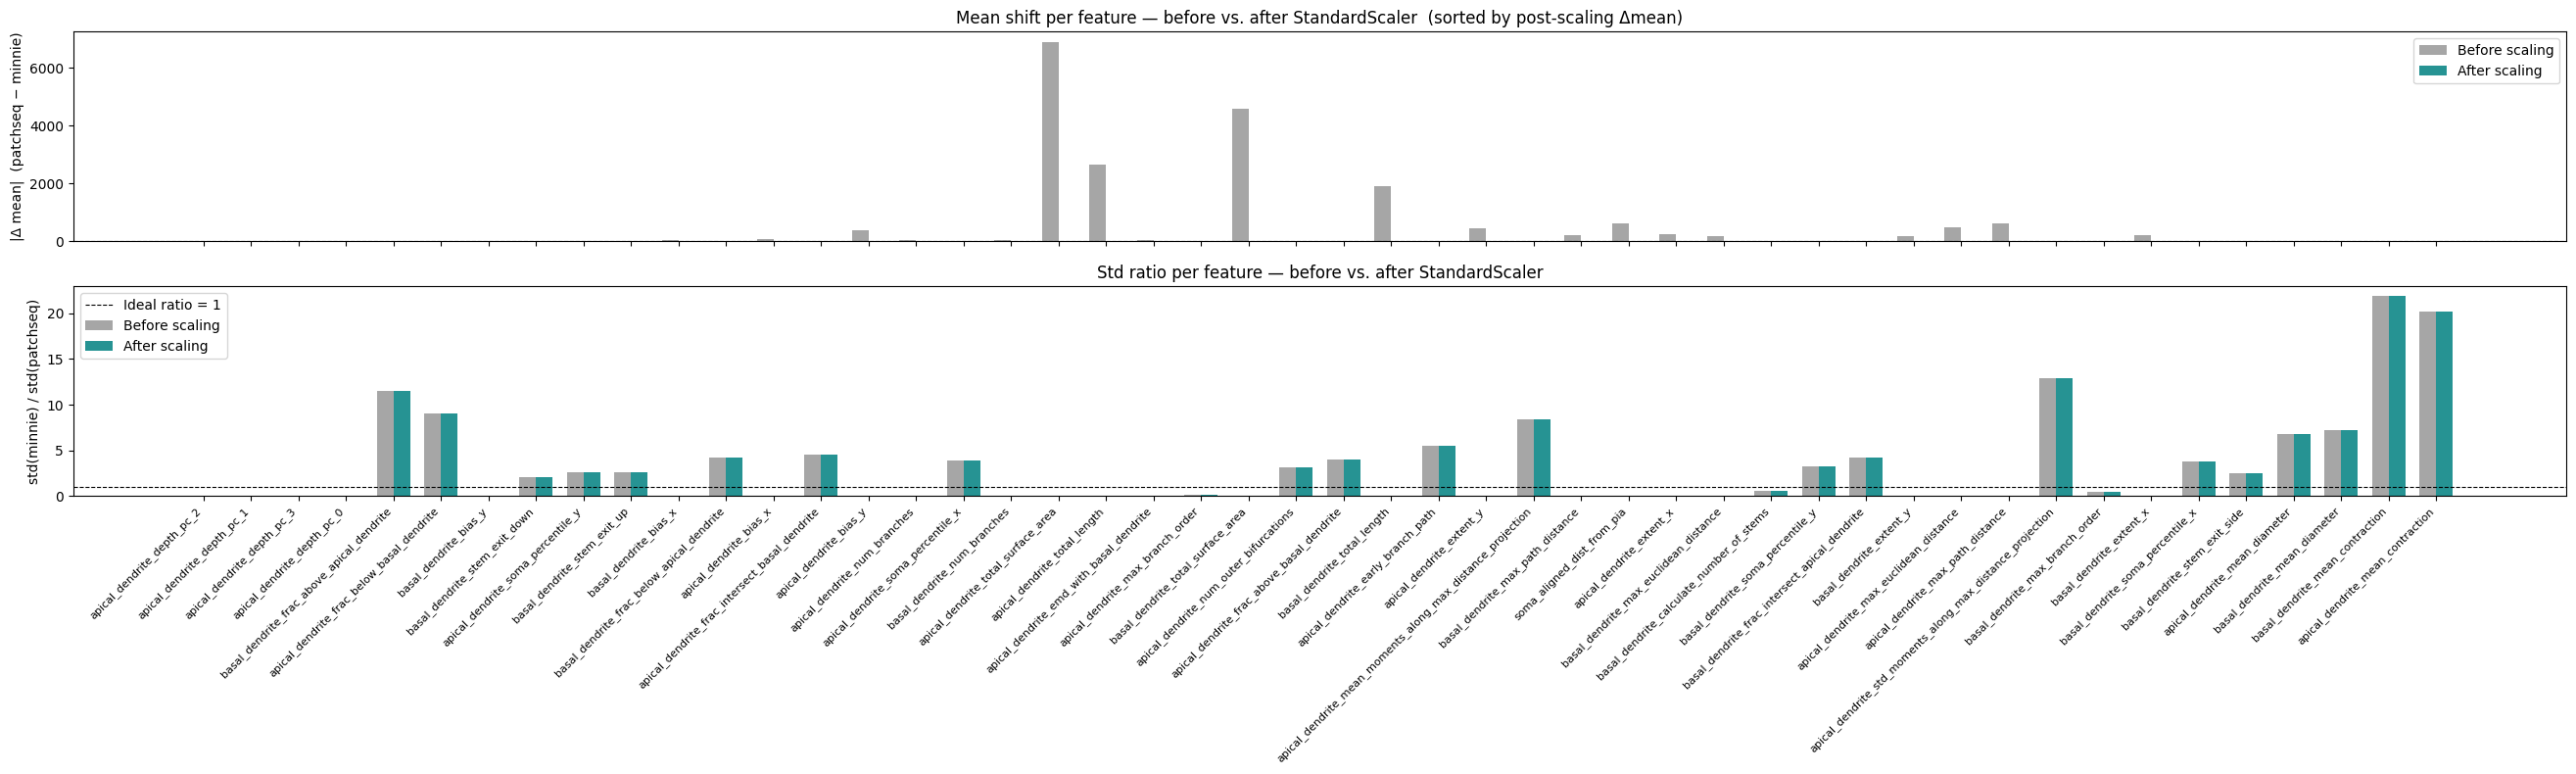

In [36]:
# ── Phase 3 Diagnostics: alignment summary bar chart (all features) ───────────
n_feats = len(alignment_df)
fig, axes = plt.subplots(2, 1, figsize=(max(12, n_feats * 0.55), 8), sharex=True)
x = np.arange(n_feats)
w = 0.35

# Top panel — |Δ mean| before vs. after
ax = axes[0]
ax.bar(x - w / 2, alignment_df["delta_mean_before"], width=w, color="grey",  alpha=0.7, label="Before scaling")
ax.bar(x + w / 2, alignment_df["delta_mean_after"],  width=w, color="teal",  alpha=0.85, label="After scaling")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("|Δ mean|  (patchseq − minnie)")
ax.set_title("Mean shift per feature — before vs. after StandardScaler  (sorted by post-scaling Δmean)")
ax.legend()

# Bottom panel — std ratio (minnie / patchseq)
ax = axes[1]
ax.bar(x - w / 2, alignment_df["std_ratio_before"], width=w, color="grey",  alpha=0.7, label="Before scaling")
ax.bar(x + w / 2, alignment_df["std_ratio_after"],  width=w, color="teal",  alpha=0.85, label="After scaling")
ax.axhline(1, color="black", linewidth=0.8, linestyle="--", label="Ideal ratio = 1")
ax.set_ylabel("std(minnie) / std(patchseq)")
ax.set_title("Std ratio per feature — before vs. after StandardScaler")
ax.set_xticks(x)
ax.set_xticklabels(alignment_df["feature"], rotation=45, ha="right", fontsize=8)
ax.legend()

fig.tight_layout()
plt.show()


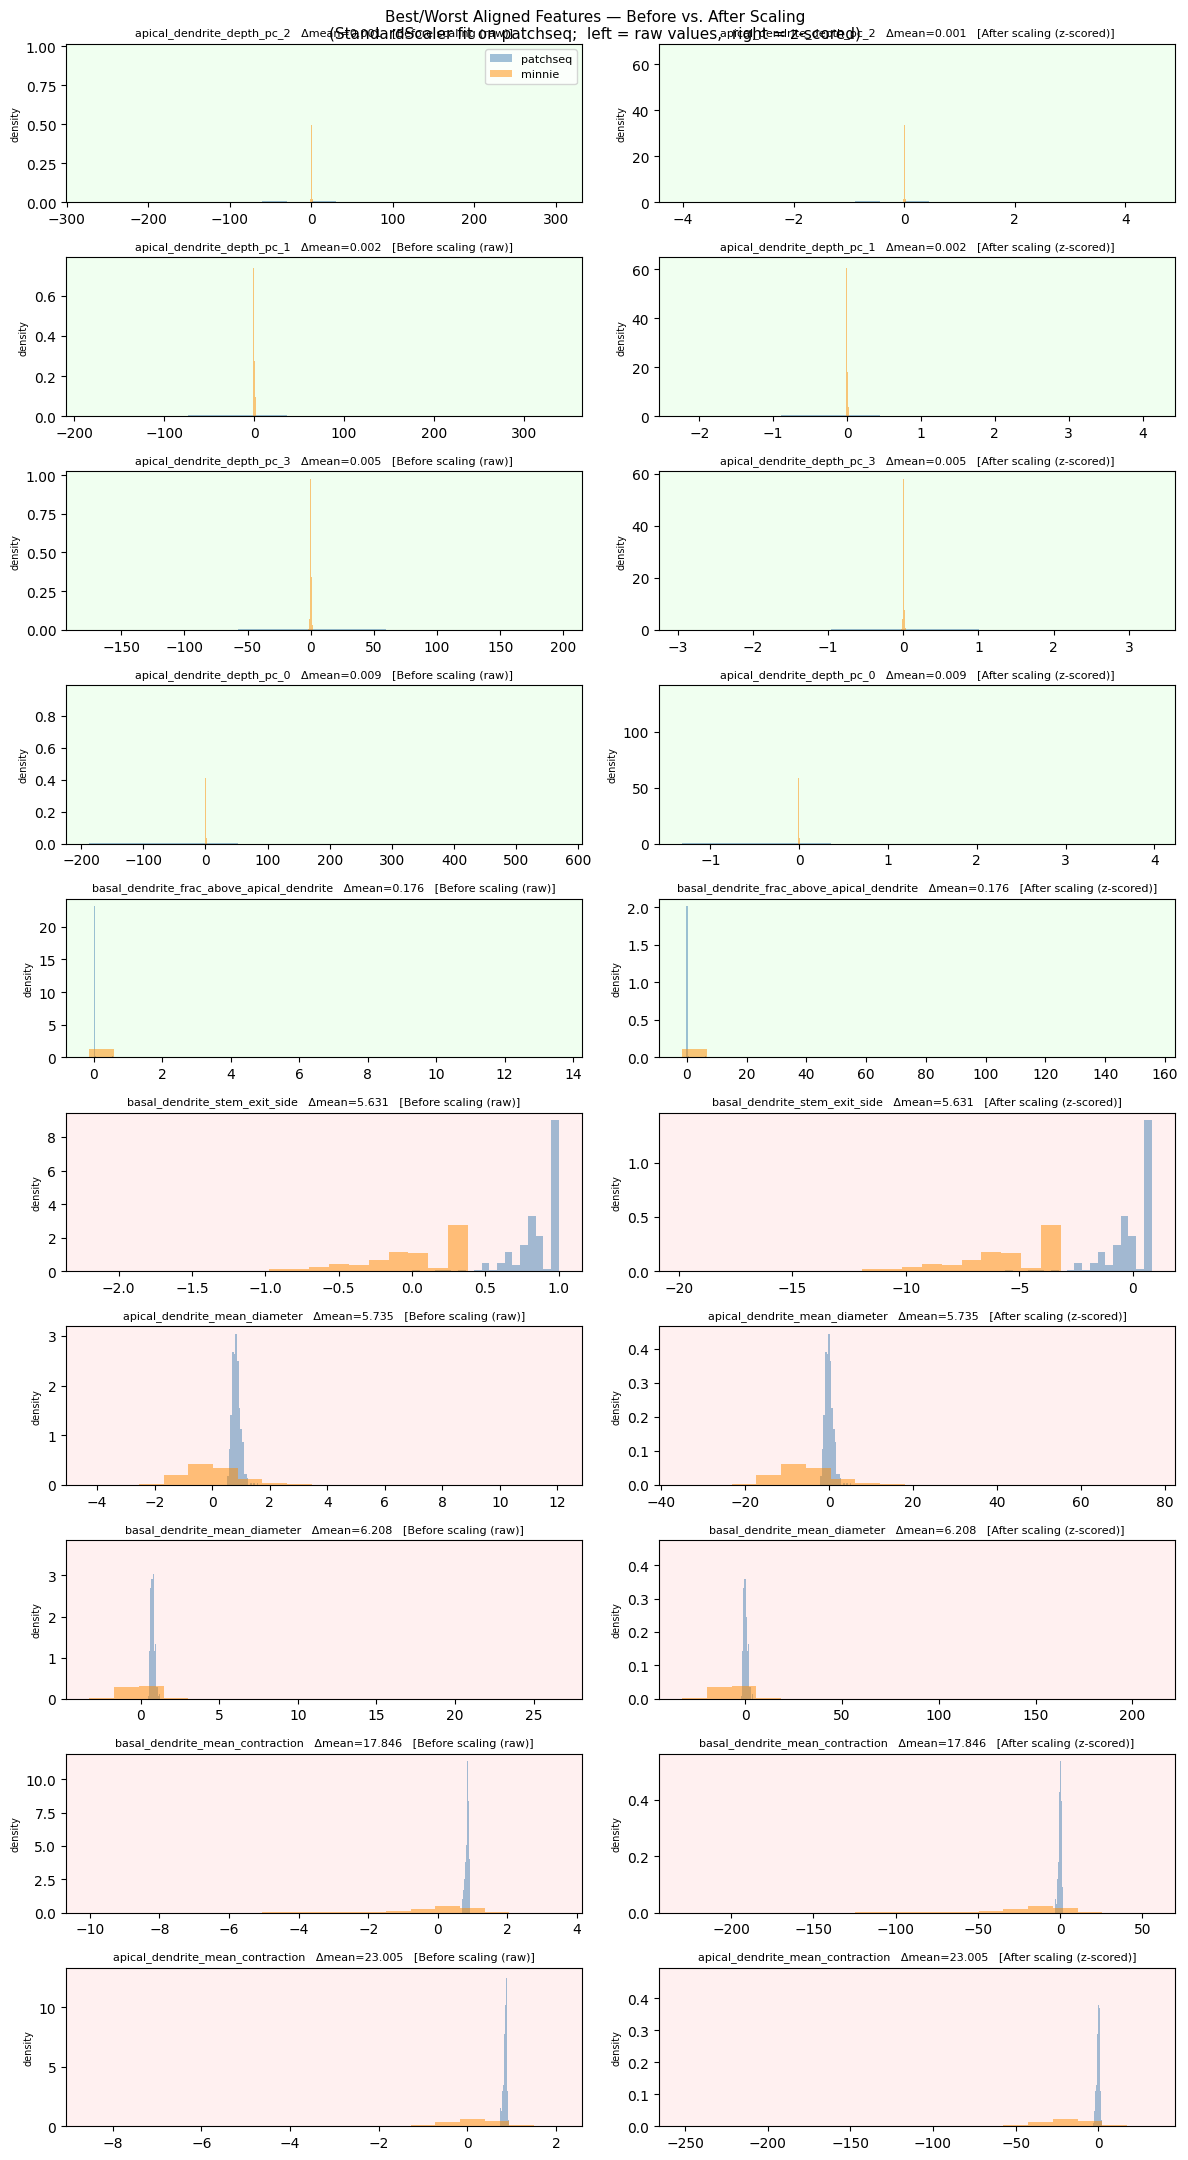

In [37]:
# ── Phase 3 Diagnostics: per-feature overlaid histograms (best & worst) ──────
TOP_N = 5  # number of best- and worst-aligned features to plot (adjust freely)
TOP_N = min(TOP_N, len(alignment_df) // 2)  # guard against too few features

best_feats  = alignment_df.head(TOP_N)["feature"].tolist()
worst_feats = alignment_df.tail(TOP_N)["feature"].tolist()
plot_feats  = best_feats + worst_feats
sections    = ["best"] * TOP_N + ["worst"] * TOP_N

n_rows = len(plot_feats)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, n_rows * 2.2), squeeze=False)
fig.suptitle(
    "Best/Worst Aligned Features — Before vs. After Scaling\n"
    "(StandardScaler fit on patchseq;  left = raw values,  right = z-scored)",
    fontsize=11,
)

BG_COLORS = {"best": "#f0fff0", "worst": "#fff0f0"}  # green tint = best, red tint = worst

for row_i, (feat, section) in enumerate(zip(plot_feats, sections)):
    feat_idx = shared_features.index(feat)
    delta    = alignment_df.loc[alignment_df["feature"] == feat, "delta_mean_after"].values[0]

    ps_raw, mn_raw = df_ps_pd[feat].values, df_mn_pd[feat].values
    ps_sc,  mn_sc  = X_ps[:, feat_idx],    X_mn[:, feat_idx]

    for col_i, (ps_vals, mn_vals, subtitle) in enumerate([
        (ps_raw, mn_raw, "Before scaling (raw)"),
        (ps_sc,  mn_sc,  "After scaling (z-scored)"),
    ]):
        ax = axes[row_i, col_i]
        ax.set_facecolor(BG_COLORS[section])
        bins = min(40, max(10, int(np.sqrt(len(ps_vals)))))
        ax.hist(ps_vals, bins=bins, density=True, alpha=0.5, color="steelblue",  label="patchseq")
        ax.hist(mn_vals, bins=bins, density=True, alpha=0.5, color="darkorange", label="minnie")
        ax.set_title(f"{feat}   Δmean={delta:.3f}   [{subtitle}]", fontsize=8)
        ax.set_ylabel("density", fontsize=7)
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


### Phase 4 — UMAP Projection

In [27]:
# Fit UMAP on patchseq; project minnie into the same embedding space
reducer = umap.UMAP(n_components=2, random_state=42, init='random')
ps_emb = reducer.fit_transform(X_ps)
mn_emb = reducer.transform(X_mn)

print(f"Patchseq embedding: {ps_emb.shape}")
print(f"Minnie embedding:   {mn_emb.shape}")

/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Patchseq embedding: (384, 2)
Minnie embedding:   (49714, 2)


### Phase 5 — KNN Label Transfer

In [24]:
from collections import Counter

In [28]:
# Fit KNN on patchseq embedding; query with minnie embedding
knn = NearestNeighbors(n_neighbors=3)
knn.fit(ps_emb)
_, indices = knn.kneighbors(mn_emb)

ps_labels = df_ps_pd['cluster'].values
neighbor_labels = ps_labels[indices]  # shape (n_minnie, 3)

# Majority vote per minnie cell
mn_predicted = np.array([
    Counter(row).most_common(1)[0][0] for row in neighbor_labels
])

print("Minnie predicted label counts:")
unique, counts = np.unique(mn_predicted, return_counts=True)
for lbl, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"  {lbl:<45} {cnt}")

Minnie predicted label counts:
  L6 IT-2                                       16590
  L4 IT                                         16196
  L6b                                           5613
  L2/3 IT                                       5498
  L6 IT-1                                       1814
  L5/L6 IT Car3                                 977
  L6 CT-2                                       877
  L5 NP                                         842
  L6 CT-1                                       723
  L5 IT-1                                       244
  L4/L5 IT                                      111
  L5 ET-2                                       64
  L6 IT-3                                       63
  L5 IT-2                                       62
  L5 IT-3 Pld5                                  40


### Phase 6 — Visualisation

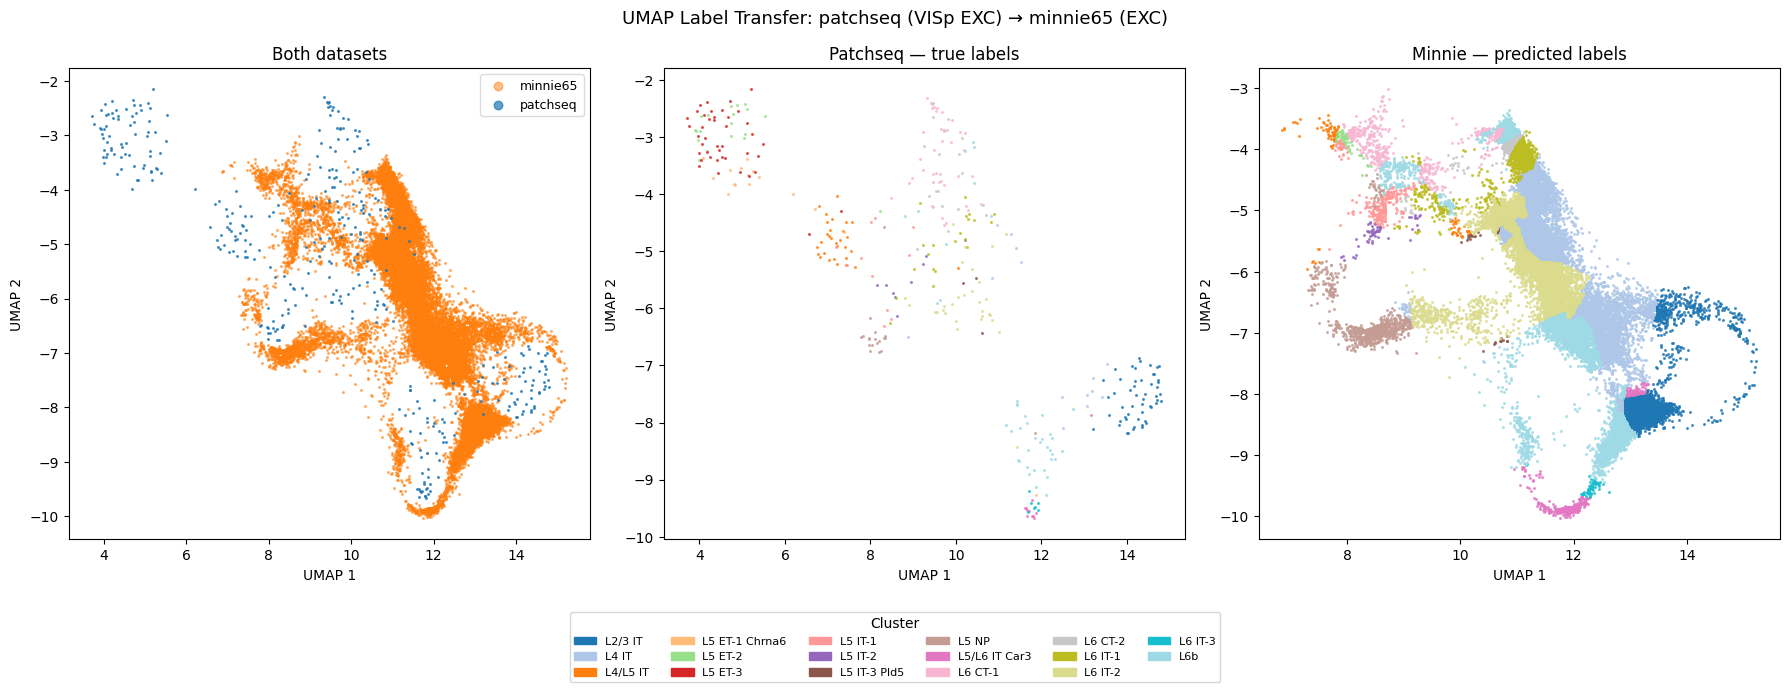

In [29]:
# ── Shared cluster colour map (tab20) ───────────────────────────────────────
all_cluster_labels = sorted(set(ps_labels) | set(mn_predicted))
cmap20 = plt.get_cmap('tab20')
cluster_colors = {
    lbl: cmap20(i / max(len(all_cluster_labels) - 1, 1))
    for i, lbl in enumerate(all_cluster_labels)
}

# Dataset-identity colours for the left panel
DS_COLORS = {'patchseq': '#1f77b4', 'minnie65': '#ff7f0e'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Left: both datasets, coloured by dataset identity ────────────────────────
ax = axes[0]
ax.scatter(mn_emb[:, 0], mn_emb[:, 1],
           c=DS_COLORS['minnie65'], s=1.5, alpha=0.5, rasterized=True, label='minnie65')
ax.scatter(ps_emb[:, 0], ps_emb[:, 1],
           c=DS_COLORS['patchseq'], s=1.5, alpha=0.7, rasterized=True, label='patchseq')
ax.set_title('Both datasets')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(markerscale=5, framealpha=0.7, fontsize=9)

# ── Middle: patchseq, coloured by true cluster label ─────────────────────────
ax = axes[1]
for lbl in all_cluster_labels:
    mask = ps_labels == lbl
    if mask.any():
        ax.scatter(ps_emb[mask, 0], ps_emb[mask, 1],
                   c=[cluster_colors[lbl]], s=1.5, alpha=0.7, rasterized=True)
ax.set_title('Patchseq — true labels')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── Right: minnie, coloured by predicted cluster label ───────────────────────
ax = axes[2]
for lbl in all_cluster_labels:
    mask = mn_predicted == lbl
    if mask.any():
        ax.scatter(mn_emb[mask, 0], mn_emb[mask, 1],
                   c=[cluster_colors[lbl]], s=1.5, alpha=0.7, rasterized=True)
ax.set_title('Minnie — predicted labels')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── Shared cluster legend (below middle + right panels) ──────────────────────
handles = [mpatches.Patch(color=cluster_colors[lbl], label=lbl) for lbl in all_cluster_labels]
fig.legend(
    handles=handles, title='Cluster',
    loc='lower center', ncol=min(len(all_cluster_labels), 6),
    bbox_to_anchor=(0.5, -0.15), framealpha=0.8, fontsize=8
)

plt.suptitle('UMAP Label Transfer: patchseq (VISp EXC) → minnie65 (EXC)', fontsize=13)
plt.tight_layout()
plt.show()